In [15]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from swot_toolkit.pipe2 import open_output_dir
from swot_toolkit.pipe4 import (
    calc_swot_metrics,
    create_swot_mosaic,
)
from swot_toolkit.swot import (
    create_raster_mosaic,
    create_raster_mosaic_2,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Baseline

In [16]:
REGION = "Rio_Branco"
DATE = "2025-09-07"


In [3]:
calc_swot_metrics(
    region_name=REGION,
    ref_date=DATE,
    metrics=["iou"],
)

Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
Processing scenario: as is
Processing scenario: exclude no data
Processing scenario: exclude bad
Processing scenario: exclude (bad, degraded)
Processing scenario: exclude (bad, degraded, suspect)


,as is,exclude no data,exclude bad,"exclude (bad, degraded)","exclude (bad, degraded, suspect)"
iou,0.554,0.5299,0.5553,0.5553,0.2772


In [5]:
calc_swot_metrics(
    region_name=REGION,
    ref_date=DATE,
    metrics=["iou"],
    version="v2",
)

Processing scenario: as is


Processing scenario: exclude no data
Processing scenario: exclude bad
Processing scenario: exclude (bad, degraded)
Processing scenario: exclude (bad, degraded, suspect)


,as is,exclude no data,exclude bad,"exclude (bad, degraded)","exclude (bad, degraded, suspect)"
iou,0.554,0.5299,0.329,0.329,0.2772


In [8]:
base_dir, aoi, _ = open_output_dir(REGION, DATE)
mosaic_df = pd.read_parquet(base_dir.parent / "dfs/swot_raster_results.parquet")

In [8]:
swot_mask, patches, no_data_masks = create_raster_mosaic(
    mosaic_df,
    ref_date=DATE,
    aoi=aoi,
    dst_crs=None,
    variable="water_frac",
    exclude_flags=None,
    exclude_no_data=False,
)


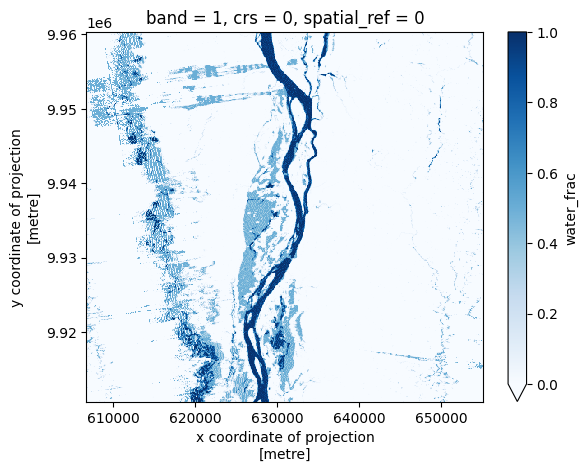

In [9]:
swot_mask["water_frac"].plot(vmin=0, vmax=1, cmap="Blues")

In [11]:
swot_mask, patches, no_data_masks = create_raster_mosaic_2(
    mosaic_df,
    ref_date=DATE,
    aoi=aoi,
    dst_crs=None,
    variable="water_frac",
    exclude_flags=[3],
    exclude_no_data=False,
)


In [12]:
patch = patches[0]

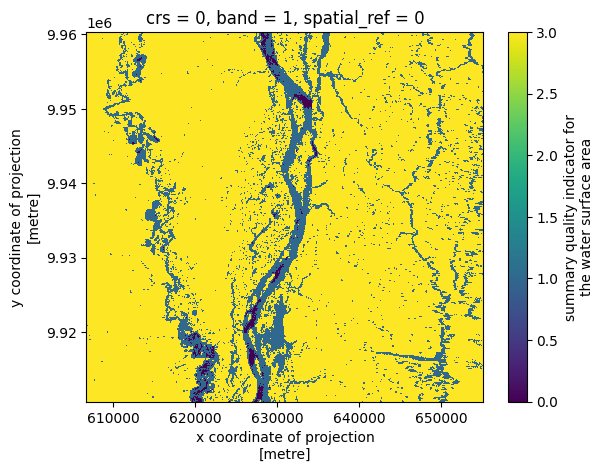

In [14]:
patch["water_area_qual"].plot()

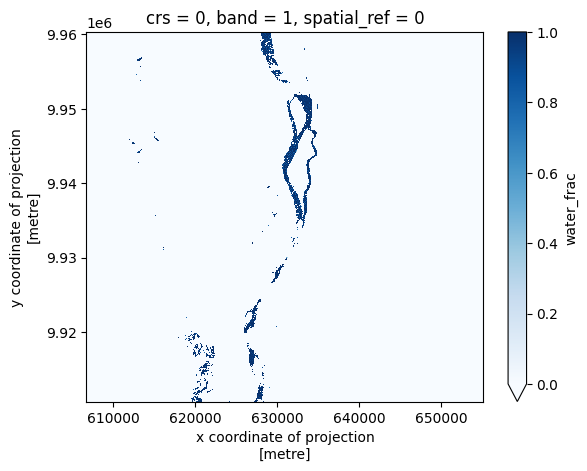

In [10]:
swot_mask["water_frac"].plot(vmin=0, vmax=1, cmap="Blues")

In [6]:
swot_ds, patches, masks = create_swot_mosaic_2(
    region_name="Rio_Branco",
    ref_date="2025-09-07",
    exclude_no_data=False,
)

NameError: name 'create_swot_mosaic_2' is not defined

In [25]:
patch = patches[1]

In [26]:
import numpy as np

np.unique(patch["water_area_qual"])

array([ 0.,  1., nan], dtype=float32)

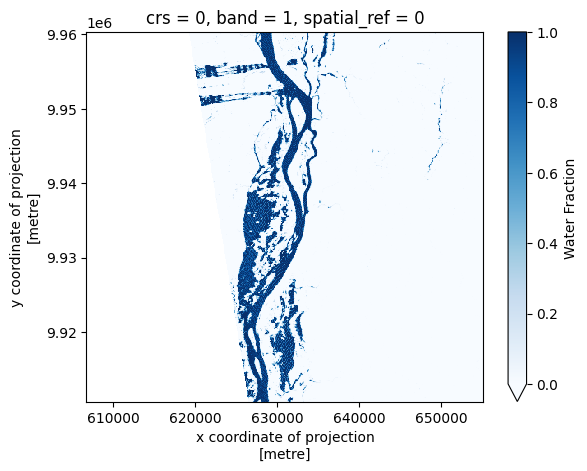

In [27]:
patch["water_frac"].plot(
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Water Fraction"},
)

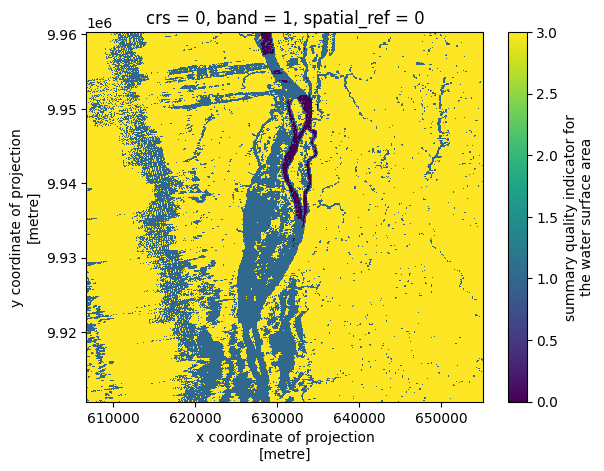

In [23]:
patch["water_area_qual"].plot()